<a href="https://colab.research.google.com/github/Wathsika/movie_recommendation_model/blob/main/movie_recommendation_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Content-Based Recommender**

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
movies=pd.read_csv('movies.csv')
ratings=pd.read_csv('ratings.csv')

In [6]:
#clean genres column
movies['genres']=movies['genres'].str.replace('|',' ')

In [7]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy
1,2,Jumanji (1995),Adventure Children Fantasy
2,3,Grumpier Old Men (1995),Comedy Romance
3,4,Waiting to Exhale (1995),Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy


In [8]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [9]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

#convert words into vectors & ignore comman words
tfidf =TfidfVectorizer(stop_words='english')
tfidf_matrix =tfidf.fit_transform(movies['genres'])
print(tfidf_matrix.toarray())

[[0.         0.41684567 0.51622547 ... 0.         0.         0.        ]
 [0.         0.51236121 0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.57860574 0.         0.81560738 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


In [11]:
print(f"Matrix Shape: {tfidf_matrix.shape}")

Matrix Shape: (9742, 23)


In [12]:
#calculate similarity using cosine similarity
from sklearn.metrics.pairwise import cosine_similarity

#calculate similarity score between every movie and every other movie
cosine_sim=cosine_similarity(tfidf_matrix,tfidf_matrix)

print(f"Similarity Matrix Shape: {cosine_sim.shape}")

Similarity Matrix Shape: (9742, 9742)


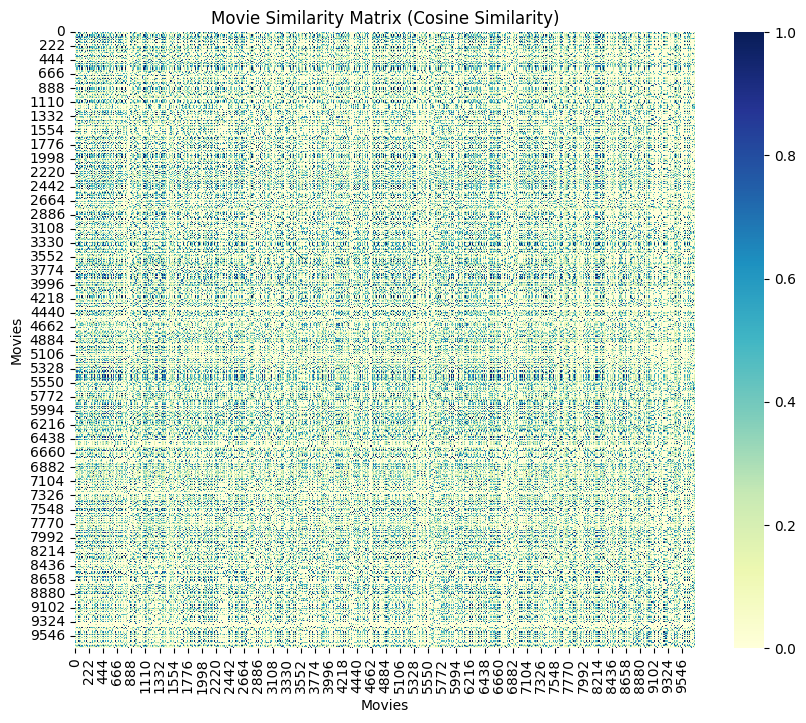

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(cosine_sim, cmap='YlGnBu')

plt.title("Movie Similarity Matrix (Cosine Similarity)")
plt.xlabel("Movies")
plt.ylabel("Movies")
plt.show()

In [14]:
title='Jumanji'
title = title.lower()
matches = movies[movies['title'].str.lower().str.contains(title, regex=False)]

if matches.empty:
        print("Not found!")

idx = matches.index[0]
movie_full_title = matches.iloc[0]['title']
movie_full_title

'Jumanji (1995)'

In [15]:
#get he score list according to idx
sim_scores = list(enumerate(cosine_sim[idx]))
sim_scores[:5]

[(0, np.float64(0.8135777407801439)),
 (1, np.float64(1.0000000000000002)),
 (2, np.float64(0.0)),
 (3, np.float64(0.0)),
 (4, np.float64(0.0))]

In [16]:
#sort to descending order
sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
sim_scores[:5]

[(1, np.float64(1.0000000000000002)),
 (53, np.float64(1.0000000000000002)),
 (109, np.float64(1.0000000000000002)),
 (767, np.float64(1.0000000000000002)),
 (1514, np.float64(1.0000000000000002))]

In [17]:
#get the similar movies
sim_scores = sim_scores[1:6]
sim_scores

[(53, np.float64(1.0000000000000002)),
 (109, np.float64(1.0000000000000002)),
 (767, np.float64(1.0000000000000002)),
 (1514, np.float64(1.0000000000000002)),
 (1556, np.float64(1.0000000000000002))]

In [18]:
#get movie id & return
movie_indices = [i[0] for i in sim_scores]
movies['title'].iloc[movie_indices]

,title
53,"Indian in the Cupboard, The (1995)"
109,"NeverEnding Story III, The (1994)"
767,Escape to Witch Mountain (1975)
1514,Darby O'Gill and the Little People (1959)
1556,Return to Oz (1985)


In [19]:
def get_recommendations(title, cosine_sim=cosine_sim):
    title_lower = title.lower()

    matches = movies[movies['title'].str.lower().str.contains(title_lower)]

    if matches.empty:
        return "Movie not found in database. Check your spelling!"

    idx = matches.index[0]
    found_title = matches.iloc[0]['title']

    print(f"--- Recommendations based on: {found_title} ---")

    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:6]

    movie_indices = [i[0] for i in sim_scores]

    return movies['title'].iloc[movie_indices]

In [20]:
print(get_recommendations("inception"))

--- Recommendations based on: Inception (2010) ---
6797          Watchmen (2009)
7625           Super 8 (2011)
8358           RoboCop (2014)
167       Strange Days (1995)
6151    V for Vendetta (2006)
Name: title, dtype: object


# **Collaborative Filtering**

In [21]:
#reorganize table
user_movie_matrix = ratings.pivot(index='movieId', columns='userId', values='rating')
user_movie_matrix.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,NaN,NaN,4.0,NaN,4.5,NaN,NaN,NaN,...,4.0,NaN,4.0,3.0,4.0,2.5,4.0,2.5,3.0,5.0
2,NaN,NaN,NaN,NaN,NaN,4.0,NaN,4.0,NaN,NaN,...,NaN,4.0,NaN,5.0,3.5,NaN,NaN,2.0,NaN,NaN
3,4.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
#fill nan by 0
user_movie_matrix = user_movie_matrix.fillna(0)
user_movie_matrix.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,0.0,0.0,4.0,0.0,4.5,0.0,0.0,0.0,...,4.0,0.0,4.0,3.0,4.0,2.5,4.0,2.5,3.0,5.0
2,0.0,0.0,0.0,0.0,0.0,4.0,0.0,4.0,0.0,0.0,...,0.0,4.0,0.0,5.0,3.5,0.0,0.0,2.0,0.0,0.0
3,4.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
#Convert to sparse matrix for Memory Optimization
from scipy.sparse import csr_matrix
sparse_matrix = csr_matrix(user_movie_matrix.values)
sparse_matrix.shape

(9724, 610)

In [24]:
#train KNN model
from sklearn.neighbors import NearestNeighbors
model_knn = NearestNeighbors(metric='cosine', algorithm='brute')
model_knn.fit(sparse_matrix)

NearestNeighbors(algorithm='brute', metric='cosine')

In [25]:
title='dark knight'

match = movies[movies['title'].str.lower().str.contains(title.lower())]
if match.empty:
  print("Movie not found.")

movie_id = match.iloc[0]['movieId']
movie_id

np.int64(58559)

In [26]:
try:
  movie_idx = user_movie_matrix.index.get_loc(movie_id)
except KeyError:
  print("Movie ID not in ratings database.")

movie_idx

6693

In [27]:
#KNN to find 6 nearest neighbors (first one is the movie itself)
distances, indices = model_knn.kneighbors(
    user_movie_matrix.iloc[movie_idx, :].values.reshape(1, -1), n_neighbors=6)

distances, indices

(array([[1.55431223e-15, 2.72736928e-01, 3.29462191e-01, 3.33945567e-01,
         3.48718465e-01, 3.79362928e-01]]),
 array([[6693, 7355, 6726, 7750, 5901, 4791]]))

In [28]:
#Convert indices back to movie titles
recommended_movie_ids = [user_movie_matrix.index[i] for i in indices.flatten()[1:]]
recommended_movie_ids

[np.int64(79132),
 np.int64(59315),
 np.int64(91529),
 np.int64(33794),
 np.int64(7153)]

In [29]:
movies[movies['movieId'].isin(recommended_movie_ids)]['title']

,title
4800,"Lord of the Rings: The Return of the King, The..."
5917,Batman Begins (2005)
6743,Iron Man (2008)
7372,Inception (2010)
7768,"Dark Knight Rises, The (2012)"


In [30]:
def get_collaborative_recommendations(movie_title):

    match = movies[movies['title'].str.lower().str.contains(movie_title.lower())]
    if match.empty:
        return "Movie not found."

    movie_id = match.iloc[0]['movieId']

    try:
        movie_idx = user_movie_matrix.index.get_loc(movie_id)
    except KeyError:
        return "Movie ID not in ratings database."

    distances, indices = model_knn.kneighbors(
        user_movie_matrix.iloc[movie_idx, :].values.reshape(1, -1),
        n_neighbors=6
    )

    recommended_movie_ids = [user_movie_matrix.index[i] for i in indices.flatten()[1:]]

    print(f"--- Users who liked '{match.iloc[0]['title']}' also liked: ---")
    return movies[movies['movieId'].isin(recommended_movie_ids)]['title']

In [31]:
get_collaborative_recommendations("iron man")

--- Users who liked 'Iron Man (2008)' also liked: ---


,title
6710,"Dark Knight, The (2008)"
6772,WALL·E (2008)
7212,Avatar (2009)
7324,Iron Man 2 (2010)
7693,"Avengers, The (2012)"


# **Hybrid Strategy**

In [59]:
title= 'inception'

match = movies[movies['title'].str.lower().str.contains(title.lower())]
if match.empty:
  print("Movie not found.")

idx = match.index[0]
movie_id = match.iloc[0]['movieId']
actual_title = match.iloc[0]['title']
actual_title

'Inception (2010)'

In [65]:
#Content filtering
sim_scores = list(enumerate(cosine_sim[idx]))
sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:21]
content_indices = [i[0] for i in sim_scores]
content_list = movies.iloc[content_indices][['movieId', 'title']]
content_list['source'] = 'Content'
content_list.head()

,movieId,title,source
6797,60684,Watchmen (2009),Content
7625,87306,Super 8 (2011),Content
8358,108945,RoboCop (2014),Content
167,198,Strange Days (1995),Content
6151,44191,V for Vendetta (2006),Content


In [70]:
#Collaborative filtering
try:
  movie_matrix_idx = user_movie_matrix.index.get_loc(movie_id)
  distances, indices = model_knn.kneighbors(user_movie_matrix.iloc[movie_matrix_idx, :].values.reshape(1, -1), n_neighbors=21)

  collab_movie_ids = [user_movie_matrix.index[i] for i in indices.flatten()[1:]]
  collab_list = movies[movies['movieId'].isin(collab_movie_ids)][['movieId', 'title']]
  collab_list['source'] = 'Collaborative'

except KeyError:
  collab_list = pd.DataFrame(columns=['movieId', 'title', 'source'])

collab_list

,movieId,title,source
1939,2571,"Matrix, The (1999)",Collaborative
2226,2959,Fight Club (1999),Collaborative
3638,4993,"Lord of the Rings: The Fellowship of the Ring,...",Collaborative
4137,5952,"Lord of the Rings: The Two Towers, The (2002)",Collaborative
4800,7153,"Lord of the Rings: The Return of the King, The...",Collaborative
6315,48516,"Departed, The (2006)",Collaborative
6331,48780,"Prestige, The (2006)",Collaborative
6710,58559,"Dark Knight, The (2008)",Collaborative
6743,59315,Iron Man (2008),Collaborative
6772,60069,WALL·E (2008),Collaborative


In [73]:
#Combine both lists

#Pre-calculate Average Ratings
movie_stats = ratings.groupby('movieId').agg({'rating': ['mean', 'count']})
movie_stats.columns = ['avg_rating', 'num_ratings']

movies_with_stats = movies.merge(movie_stats, on='movieId', how='left').fillna(0)
movies_with_stats.head()

,movieId,title,genres,avg_rating,num_ratings
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy,3.920930,215.0
1,2,Jumanji (1995),Adventure Children Fantasy,3.431818,110.0
2,3,Grumpier Old Men (1995),Comedy Romance,3.259615,52.0
3,4,Waiting to Exhale (1995),Comedy Drama Romance,2.357143,7.0
4,5,Father of the Bride Part II (1995),Comedy,3.071429,49.0


In [74]:
hybrid_list = pd.concat([content_list, collab_list]).drop_duplicates(subset='movieId')
hybrid_list = hybrid_list.merge(movies_with_stats[['movieId', 'avg_rating', 'num_ratings']], on='movieId')
hybrid_list

,movieId,title,source,avg_rating,num_ratings
0,60684,Watchmen (2009),Content,3.988372,43.0
1,87306,Super 8 (2011),Content,3.595238,21.0
2,108945,RoboCop (2014),Content,2.333333,6.0
3,198,Strange Days (1995),Content,3.250000,28.0
4,44191,V for Vendetta (2006),Content,3.885000,100.0
5,53996,Transformers (2007),Content,3.346154,39.0
6,85056,I Am Number Four (2011),Content,3.100000,5.0
7,94018,Battleship (2012),Content,2.333333,3.0
8,102125,Iron Man 3 (2013),Content,3.562500,32.0
9,104243,Riddick (2013),Content,3.300000,5.0


In [75]:
recommendations = hybrid_list.sort_values(by='avg_rating', ascending=False).head(10)
recommendations

,movieId,title,source,avg_rating,num_ratings
21,2959,Fight Club (1999),Collaborative,4.272936,218.0
25,48516,"Departed, The (2006)",Collaborative,4.252336,107.0
27,58559,"Dark Knight, The (2008)",Collaborative,4.238255,149.0
20,2571,"Matrix, The (1999)",Collaborative,4.192446,278.0
30,68157,Inglourious Basterds (2009),Collaborative,4.136364,88.0
24,7153,"Lord of the Rings: The Return of the King, The...",Collaborative,4.118919,185.0
22,4993,"Lord of the Rings: The Fellowship of the Ring,...",Collaborative,4.106061,198.0
29,60069,WALL·E (2008),Collaborative,4.057692,104.0
34,74458,Shutter Island (2010),Collaborative,4.022388,67.0
23,5952,"Lord of the Rings: The Two Towers, The (2002)",Collaborative,4.021277,188.0


In [76]:
def get_hybrid_recommendations(movie_input):
    # --- 1. Find the movie index ---
    match = movies[movies['title'].str.lower().str.contains(movie_input.lower())]
    if match.empty: return "Movie not found."

    idx = match.index[0]
    movie_id = match.iloc[0]['movieId']
    actual_title = match.iloc[0]['title']

    # --- 2. Get Content-Based Candidates (Top 20) ---
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:21]
    content_indices = [i[0] for i in sim_scores]
    content_list = movies.iloc[content_indices][['movieId', 'title']]
    content_list['source'] = 'Content'

    # --- 3. Get Collaborative Candidates (Top 20) ---
    try:
        movie_matrix_idx = user_movie_matrix.index.get_loc(movie_id)
        distances, indices = model_knn.kneighbors(
            user_movie_matrix.iloc[movie_matrix_idx, :].values.reshape(1, -1),
            n_neighbors=21
        )
        collab_movie_ids = [user_movie_matrix.index[i] for i in indices.flatten()[1:]]
        collab_list = movies[movies['movieId'].isin(collab_movie_ids)][['movieId', 'title']]
        collab_list['source'] = 'Collaborative'
    except KeyError:
        collab_list = pd.DataFrame(columns=['movieId', 'title', 'source'])

    # --- 4. Merge and Rank ---
    # Combine both lists
    hybrid_list = pd.concat([content_list, collab_list]).drop_duplicates(subset='movieId')

    # Merge with our stats to get ratings
    hybrid_list = hybrid_list.merge(movies_with_stats[['movieId', 'avg_rating', 'num_ratings']], on='movieId')

    # SCORE FORMULA:
    # We want movies that appear in both or have high ratings.
    # For simplicity: Sort by Average Rating (of movies that passed the similarity filter)
    # This ensures we recommend "Good" similar movies.
    recommendations = hybrid_list.sort_values(by='avg_rating', ascending=False).head(10)

    print(f"--- Hybrid Recommendations for '{actual_title}' ---")
    return recommendations[['title', 'avg_rating', 'source']]

In [77]:
get_hybrid_recommendations("toy story")

--- Hybrid Recommendations for 'Toy Story (1995)' ---


,title,avg_rating,source
8,Asterix and the Vikings (Astérix et les Viking...,5.000000,Content
25,"Shawshank Redemption, The (1994)",4.429022,Collaborative
23,Star Wars: Episode IV - A New Hope (1977),4.231076,Collaborative
33,Star Wars: Episode V - The Empire Strikes Back...,4.215640,Collaborative
24,Pulp Fiction (1994),4.197068,Collaborative
26,Forrest Gump (1994),4.164134,Collaborative
34,Star Wars: Episode VI - Return of the Jedi (1983),4.137755,Collaborative
36,Back to the Future (1985),4.038012,Collaborative
20,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),3.983051,Collaborative
35,Groundhog Day (1993),3.944056,Collaborative


# **save model**

In [78]:
import pickle

# Create dictionary to store data
model_data = {
    'movies': movies_with_stats,
    'cosine_sim': cosine_sim,
    'user_movie_matrix': user_movie_matrix,
    'model_knn': model_knn,
    'ratings': ratings
}

In [79]:
with open('movie_recommender_data.pkl', 'wb') as f:
    pickle.dump(model_data, f)